In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split     #veriyi eğitim ve test için bölme
from sklearn.preprocessing import MinMaxScaler     #ölçeklendirme
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model     #modeli kurma ve kaydetme
from tensorflow.keras.layers import Dense     #modele katman ekleme
from tensorflow.keras.callbacks import EarlyStopping     #belli süre boyunca hata kaybı azalamıyorsa erkenden durdurma

df=pd.read_csv("hakem.csv")
x=df.drop("sonrakiP",axis=1).values     #tahmin için öğrenilecek özellikler
y=df["sonrakiP"].values     #öğrenilen özelliklerden hangi özellik için tahmin çıkarılacağı
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.32,random_state=42,shuffle=True)     #verinin %32'si teste ayrılsın

scaler=MinMaxScaler()     #veriler 0-1 arası değerler olarak değiştirme
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

#val_loss'un yükselmesi overfitting göstergesidir, min değerini ararız, min değerden sonraki 20 adımda yeni min çıkmamışsa veriyi öğrenmeyi bıraksın
earlyStop=EarlyStopping(monitor="val_loss", mode="min", verbose=1, patience=20, restore_best_weights=True)

model=Sequential()     #model kuruldu
#2 katmanlı yapı
model.add(Dense(units=8,activation="relu"))     #bu katmanda 8 nöron olacak
model.add(Dense(units=4,activation="relu"))
model.add(Dense(units=1))     #çıktı katmanı (1 sonuç verilecek)
#optimizer, öğrenme oranını (daha az loss için atılacak adım büyüklüğünü) ayarlar; loss, tahmin-gerçek arası hatayı ölçer
model.compile(optimizer="adam", loss="mse")
#x_train'i, y_train ile eğitme; epochs, verilerin kaç kez gezileceğini (öğrenileceğini); batch_size, verilerin modele kaçar kaçar yükleneceğini söyler
model.fit(x_train,y_train,validation_data=(x_test,y_test),batch_size=5,callbacks=[earlyStop],epochs=400)

model.save("hakemAnalizi.h5")     #modeli kaydetme
joblib.dump(scaler,"hakemScaler.pkl")     #ölçeklendiriciyi kaydetme

Epoch 1/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 4304.4941 - val_loss: 3322.3694
Epoch 2/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4287.0093 - val_loss: 3308.1094
Epoch 3/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4269.2285 - val_loss: 3292.1958
Epoch 4/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4249.4473 - val_loss: 3274.3589
Epoch 5/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4227.8555 - val_loss: 3255.0134
Epoch 6/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4205.8330 - val_loss: 3234.5715
Epoch 7/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4181.5566 - val_loss: 3213.1990
Epoch 8/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4155.5161 - val_loss: 3191.1624
Epoch 9/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4128.1162 - val_loss: 3167.9397
Epoch 10/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4100.6494 - val_loss: 3141.6174
Epoch 11/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 4069.5381 - val_lo

['hakemScaler.pkl']

<Axes: >

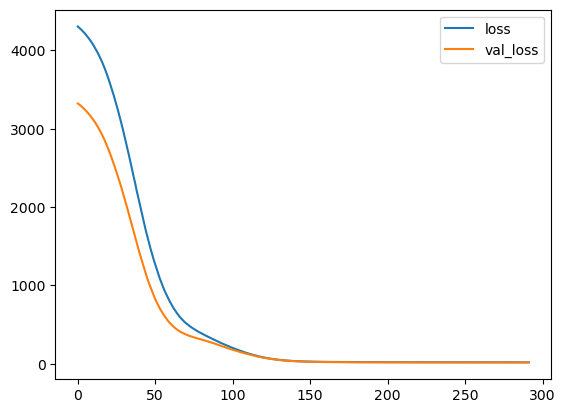

In [65]:
#kayıp grafiği (loss, elindeki verileri; val_loss, dışardan gelen/bilmediği verileri ne kadar yanlış tahmin ettiğini söyler)
loss=pd.DataFrame(model.history.history)
loss.plot()

In [94]:
yeniSinav=[[18,2,0,90]]
yeniSinav=scaler.transform(yeniSinav)
print(f"Sonraki sınav sonucu tahmini: {model.predict(yeniSinav)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Sonraki sınav sonucu tahmini: [[90.16731]]
